# Position, with the sensor in the loop

The PMSM as a stepper, then as a servo. `coaxial.motion` is the API; the
physics underneath is one spring: HOLD commutates on the COMMANDED angle
and the rotor hangs off it by the load angle, torque `amps kt sin(delta)`.
Everything a stepper does - follow, ring, slip - follows from that.

Against the stand-in, whose shaft sensor reads the same virtual rotor
the drive torques. At the bench: `SIMULATED = False`, the A1335 needs a
magnet, and the angle frame is INCREMENTAL - absolute needs an encoder
offset nothing has commissioned yet.

In [1]:
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

root = Path.cwd()
while not (root / 'host' / 'coaxial').is_dir():
    root = root.parent
sys.path.insert(0, str(root / 'host'))

from coaxial import Coaxial63100

SIMULATED = True                    # False at the bench
PORT = 'COM4'

BLUE, RED, GREY = '#1f4e79', '#c0392b', '#95a5a6'
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.15})

rig = Coaxial63100(port=PORT, simulated_device=SIMULATED,
                   power_afe=False).open()
rig.drive.source('model')           # the virtual rotor; 'adc' at the bench
rig.gates.arm(bypass_sto=True, ignore_interlock=True)
print(rig)

<Coaxial63100 Simulated SIMULATED>


## Open loop: the stepper bargain

`to()` slews the command and trusts the rotor to follow. The trace reads
the shaft at ~100 Hz while it moves: the follow is real, and so is the
ring after the stop - the spring is nearly undamped, and this machine
rings at tens of hertz for tenths of a second.

command ended at 20.0 deg


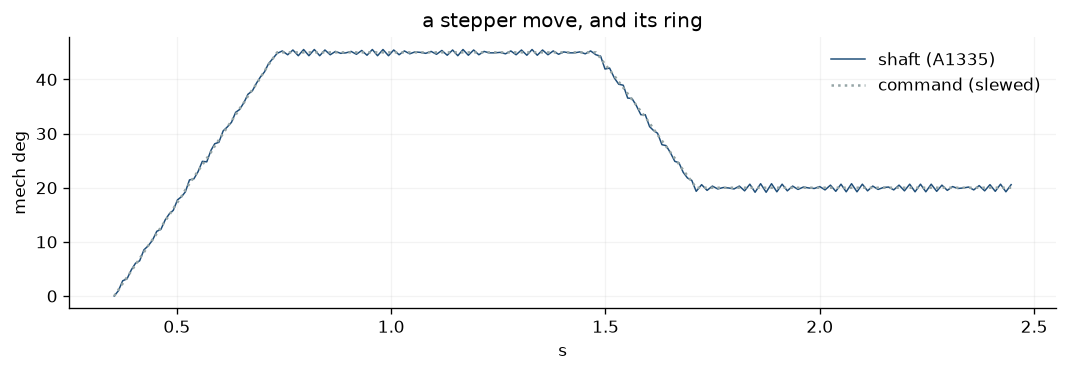

In [2]:
log = []
t0 = time.perf_counter()


def sample(cmd):
    log.append((time.perf_counter() - t0, cmd,
                rig.angle.state()['degrees']))


with rig.motion.stepper(amps=3.0, deg_s=120.0) as m:
    for leg in (np.linspace(0, 45, 40), np.linspace(45, 20, 24)):
        for tgt in leg:                  # 1-degree chunks, sampled between
            m.to(float(tgt))
            sample(m.position)
        for _ in range(60):              # then watch the ring die out
            sample(m.position)
            time.sleep(0.012)
    print('command ended at %.1f deg' % m.position)

t_s, cmd, shaft = np.array(log).T
shaft = np.unwrap(shaft, period=360.0)
shaft -= shaft[0]
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(t_s, shaft, color=BLUE, lw=0.9, label='shaft (A1335)')
ax.plot(t_s, cmd, color=GREY, ls=':', label='command (slewed)')
ax.set(xlabel='s', ylabel='mech deg', title='a stepper move, and its ring')
ax.legend(frameon=False)
fig.tight_layout()

## Why the servo corrects between moves, not per pass

The ring above sits near the correction rate any link-driven loop could
manage, so a per-pass position loop samples its own resonance ALIASED -
tried, and six clean passes pumped the rotor through a pole slip into a
freewheel. `motion.Servo` therefore closes the loop once per MOVE: slew,
let the ring die, read the sensor as a short mean (the ring is symmetric
about the equilibrium), correct what the load stole.

In [3]:
with rig.motion.servo(amps=3.0) as s:
    got = s.to(30.0, tol=0.5)
    print('asked 30.00, shaft %.2f  (error %+.2f)' % (got, s.error))

    # Now steal some torque: a standing load on the virtual rotor - at
    # the bench this is a weight on the arm. The spring winds, the shaft
    # sags, and the next correction takes the sag back out.
    rig.drive.model_param(load=0.06)     # N m, about 40 % of holding
    time.sleep(0.5)
    sag = s._measure()
    got = s.to(30.0, tol=0.5)
    rig.drive.model_param(load=0.0)
    print('loaded: sagged to %.2f, corrected to %.2f' % (sag, got))

asked 30.00, shaft 30.05  (error -0.05)


loaded: sagged to 26.12, corrected to 29.67


## What the bench adds

The stand-in's sensor is perfectly aligned by construction. A real A1335
adds the magnet's mounting offset and the pole-pair ambiguity, so the
absolute frame needs one commissioning move against a known feature -
until then every block's zero is wherever the soft energize detented.
Holding torque is `amps kt`: 3 A on the placeholder profile is about
0.16 N m, and the sag test above is the measurement that says so.